In [12]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np
from scipy import stats as sts

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Simplificar do dataset para facilitar o uso de filtros

In [2]:
file = "yellow_tripdata_2015-01.parquet"
silver_path = Path().cwd().parent / "data" / "silver" / file
df = pl.read_parquet(silver_path)
df.head(10)

vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,datetime[μs],datetime[μs],i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8
1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8
1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8
1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3
1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.2,-73.983276,40.726009,1,"""N""",-73.99247,40.749634,2,14.0,0.5,0.5,0.0,0.0,0.3,15.3
1,2015-01-10 20:33:39,2015-01-10 20:42:20,3,0.8,-74.002663,40.734142,1,"""N""",-73.99501,40.726326,1,7.0,0.5,0.5,1.66,0.0,0.3,9.96
1,2015-01-10 20:33:40,2015-01-10 20:40:44,2,0.9,-73.985588,40.767948,1,"""N""",-73.985916,40.759365,1,6.5,0.5,0.5,1.55,0.0,0.3,9.35
1,2015-01-10 20:33:40,2015-01-10 20:41:39,1,0.9,-73.988617,40.723103,1,"""N""",-74.004395,40.728584,1,7.0,0.5,0.5,1.66,0.0,0.3,9.96


## Correlações direta: Distância x Preço


A correlação entre distância e preço é:
shape: (1, 1)
┌───────────────┐
│ trip_distance │
│ ---           │
│ f64           │
╞═══════════════╡
│ 0.920509      │
└───────────────┘


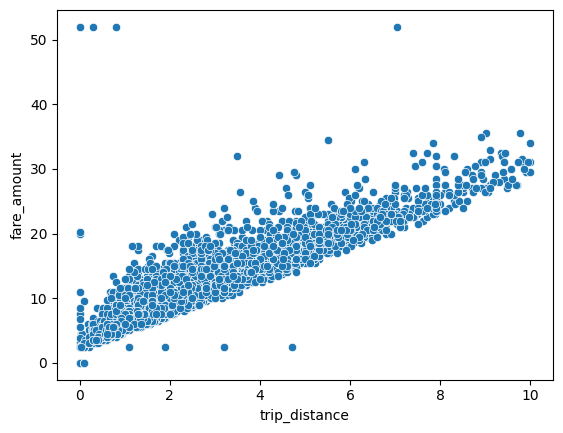

In [3]:
cr_distancia_preco = df.select(pl.corr("trip_distance", "fare_amount"))

print("A correlação entre distância e preço é:")
print(cr_distancia_preco)

sns.scatterplot(data=df.sample(10000), x="trip_distance", y="fare_amount")
plt.show()

## Correlações direta: Número de Passageiros x Preço



Média de preço de acordo com o número de passageiros:
shape: (4, 3)
┌─────────────────┬─────────────┬──────────────┐
│ passenger_count ┆ preco_medio ┆ qtd_corridas │
│ ---             ┆ ---         ┆ ---          │
│ i64             ┆ f64         ┆ u32          │
╞═════════════════╪═════════════╪══════════════╡
│ 1               ┆ 9.640192    ┆ 8098702      │
│ 2               ┆ 9.833752    ┆ 1616562      │
│ 3               ┆ 9.849736    ┆ 476790       │
│ 4               ┆ 9.897103    ┆ 228230       │
└─────────────────┴─────────────┴──────────────┘


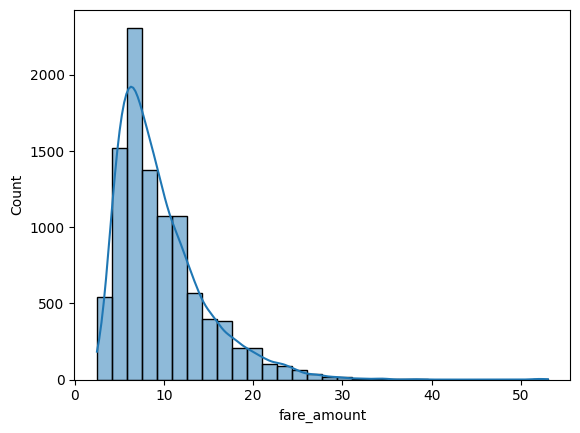

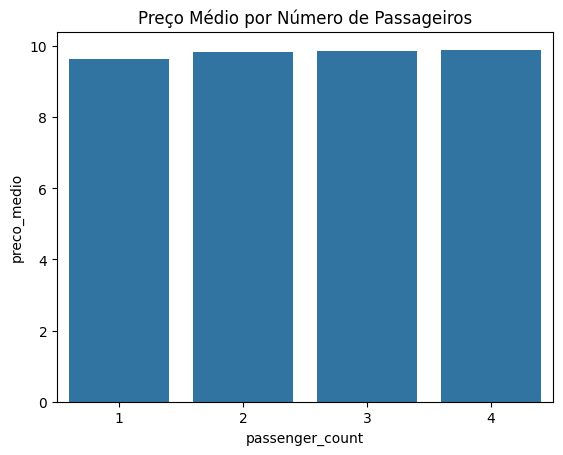

In [4]:
analise_passageiros = df.group_by("passenger_count").agg(
    pl.col("fare_amount").mean().alias("preco_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("passenger_count")

print("\nMédia de preço de acordo com o número de passageiros:")
print(analise_passageiros)

sns.histplot(
    data=df.filter(pl.col("fare_amount").is_between(0, 60)).sample(10000).to_pandas(), 
    x="fare_amount", 
    kde=True, 
    bins=30
)
plt.show()

sns.barplot(
    data=analise_passageiros.to_pandas(), 
    x="passenger_count", 
    y="preco_medio"
)
plt.title("Preço Médio por Número de Passageiros")
plt.show()

## Correlação direta: Tempo x Preço

A correlação entre tempo e preço é: 0.1644


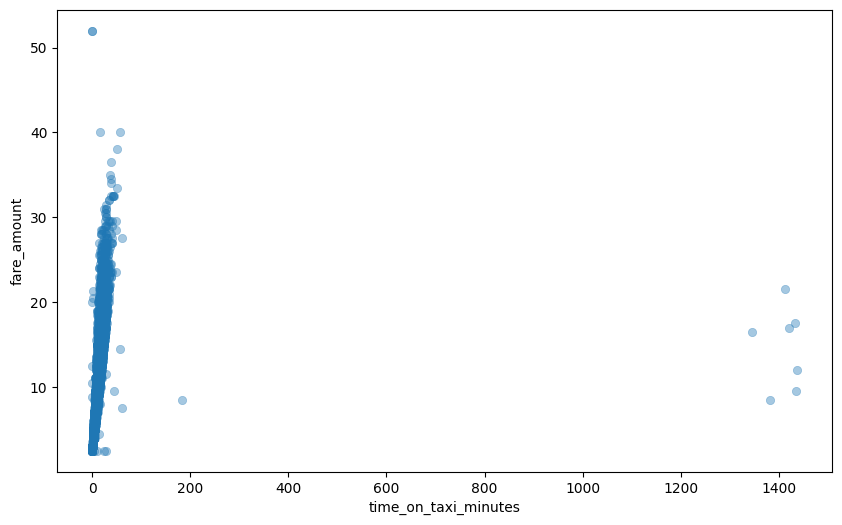

In [5]:
df_tempo_taxi = df.with_columns([
    (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_minutes()
    .alias("time_on_taxi_minutes")
])

cr_tempo_preco = df_tempo_taxi.select(
    pl.corr("time_on_taxi_minutes", "fare_amount")
).item() # .item() extrai o valor numérico direto da tabela

print(f"A correlação entre tempo e preço é: {cr_tempo_preco:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_tempo_taxi.sample(10000).to_pandas(),
    x="time_on_taxi_minutes", 
    y="fare_amount",
    alpha=0.4,
    edgecolor=None
)
plt.show()

## Correlação Indireta: Forma de Pagamento X Preço

In [6]:
analise_pagamento = df.group_by("payment_type").agg(
    pl.col("fare_amount").mean().alias("preco_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("payment_type", descending=False)

print("Média de preço por tipo de pagamento:")
print(analise_pagamento)

Média de preço por tipo de pagamento:
shape: (5, 3)
┌──────────────┬─────────────┬──────────────┐
│ payment_type ┆ preco_medio ┆ qtd_corridas │
│ ---          ┆ ---         ┆ ---          │
│ i64          ┆ f64         ┆ u32          │
╞══════════════╪═════════════╪══════════════╡
│ 1            ┆ 9.88679     ┆ 6318111      │
│ 2            ┆ 9.379059    ┆ 4060941      │
│ 3            ┆ 8.820372    ┆ 32639        │
│ 4            ┆ 9.71315     ┆ 8591         │
│ 5            ┆ 3.0         ┆ 2            │
└──────────────┴─────────────┴──────────────┘


## Correlação Indireta: Gorjeta x Pagamento Em dinheiro

In [7]:
analise_pagamento_dinheiro = df.group_by("payment_type").agg(
    pl.col("tip_amount").mean().alias("gorjeta_medio"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("payment_type", descending=False)

print("Gorjeta por pagamento em dinheiro:")
print(analise_pagamento_dinheiro)

Gorjeta por pagamento em dinheiro:
shape: (5, 3)
┌──────────────┬───────────────┬──────────────┐
│ payment_type ┆ gorjeta_medio ┆ qtd_corridas │
│ ---          ┆ ---           ┆ ---          │
│ i64          ┆ f64           ┆ u32          │
╞══════════════╪═══════════════╪══════════════╡
│ 1            ┆ 1.927128      ┆ 6318111      │
│ 2            ┆ 0.000065      ┆ 4060941      │
│ 3            ┆ 0.000996      ┆ 32639        │
│ 4            ┆ 0.001946      ┆ 8591         │
│ 5            ┆ 0.0           ┆ 2            │
└──────────────┴───────────────┴──────────────┘


## Correlação Indireta: Extra x relação a hora da corrida

In [8]:
df_hora = df.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("hora_do_dia")
])

analise_rush = df_hora.group_by("hora_do_dia").agg(
    pl.col("extra").mean().alias("media_taxa_extra"),
    pl.col("fare_amount").mean().alias("preco_medio_corrida"),
    pl.col("fare_amount").count().alias("qtd_corridas")
).sort("hora_do_dia")

print("Análise de taxas e preços por hora do dia:")
print(analise_rush)

Análise de taxas e preços por hora do dia:
shape: (24, 4)
┌─────────────┬──────────────────┬─────────────────────┬──────────────┐
│ hora_do_dia ┆ media_taxa_extra ┆ preco_medio_corrida ┆ qtd_corridas │
│ ---         ┆ ---              ┆ ---                 ┆ ---          │
│ i8          ┆ f64              ┆ f64                 ┆ u32          │
╞═════════════╪══════════════════╪═════════════════════╪══════════════╡
│ 0           ┆ 0.498496         ┆ 10.51122            ┆ 380566       │
│ 1           ┆ 0.49831          ┆ 10.673361           ┆ 290010       │
│ 2           ┆ 0.497874         ┆ 10.812048           ┆ 219381       │
│ 3           ┆ 0.497041         ┆ 10.96194            ┆ 159313       │
│ 4           ┆ 0.496016         ┆ 11.166558           ┆ 108772       │
│ …           ┆ …                ┆ …                   ┆ …            │
│ 19          ┆ 0.668657         ┆ 9.415257            ┆ 670810       │
│ 20          ┆ 0.502195         ┆ 9.542487            ┆ 604801       │
│ 21  

## Regressão linear e intervalo de confiança: Distancia x Preço

In [16]:
X = df.select(["trip_distance"]).to_pandas() 
y = df.select("fare_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Erro Médio (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")

distancia_teste = [[10]]
previsao = lr.predict(distancia_teste)
print(f"\nPrevisão para 10 milhas: ${previsao[0][0]:.2f}")
print(f"Coeficiente original: ${lr.coef_[0][0]:.4f}")

dados_treino = np.column_stack((X_train.values.flatten(), y_train.values.flatten()))

np.random.seed(42)
indices_amostra = np.random.choice(len(dados_treino), size=50000, replace=False)
dados_amostra = dados_treino[indices_amostra]

print(f"\nDataset original: {len(dados_treino):,} linhas")
print(f"Amostra para bootstrap: {len(dados_amostra):,} linhas")

print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_bootstrap = []
X_amostra = dados_amostra[:, 0]
y_amostra = dados_amostra[:, 1]
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx].reshape(-1, 1), y_amostra[idx])
    coefs_bootstrap.append(modelo.coef_[0])
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

coefs_bootstrap = np.array(coefs_bootstrap)
ic_inferior = np.percentile(coefs_bootstrap, 2.5)
ic_superior = np.percentile(coefs_bootstrap, 97.5)

print(f"\nIntervalo de confiança do custo por milha (95%): ({ic_inferior:.4f}, {ic_superior:.4f})")

R² Score: 0.8470
Erro Médio (MAE): $1.22

Previsão para 10 milhas: $33.34
Coeficiente original: $2.9606


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 7,815,213 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

Intervalo de confiança do custo por milha (95%): (2.9375, 2.9683)


## Teste de Hipótese para o Coeficiente de Regressão (Custo por Milha)

### 1. Formulação das Hipóteses

Queremos verificar se a distância da viagem (`trip_distance`) tem um efeito estatisticamente significativo sobre o valor da tarifa (`fare_amount`).

- **Hipótese Nula ($H_0$):** O custo por milha é igual a zero ($\beta = 0$).  
  *Interpretação:* A distância percorrida não afeta o preço da corrida.

- **Hipótese Alternativa ($H_1$):** O custo por milha é diferente de zero ($\beta \neq 0$).  
  *Interpretação:* A distância percorrida tem influência real no valor cobrado.

### 2. Método Estatístico

Utilizamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir um **intervalo de confiança de 95%** para o coeficiente $\beta$.  
O bootstrap é uma técnica robusta que não depende de suposições de normalidade dos resíduos.

**Procedimento:**
1. Selecionamos uma amostra aleatória de 50.000 observações do conjunto de treino (para viabilizar computacionalmente).
2. Em cada uma das 2.500 iterações, sorteamos uma nova amostra **com reposição** do mesmo tamanho.
3. Ajustamos um modelo de regressão linear simples em cada amostra bootstrap e armazenamos o coeficiente angular.
4. Calculamos os percentis 2,5% e 97,5% da distribuição dos coeficientes para obter o IC 95%.

### 3. Regra de Decisão

- **Se o valor 0 (zero) estiver DENTRO do intervalo de confiança**, não rejeitamos $H_0$.  
  *Conclusão:* Não há evidências suficientes para afirmar que a distância impacta a tarifa.

- **Se o valor 0 estiver FORA do intervalo de confiança**, rejeitamos $H_0$ ao nível de significância de 5%.  
  *Conclusão:* Existe uma relação estatisticamente significativa entre distância e tarifa.

### 4. Resultados Obtidos

| Estatística | Valor |
|-------------|-------|
| Coeficiente original (amostra completa) | `$2.9606` |
| Intervalo de Confiança 95% (Bootstrap) | `(2.9375, 2.9683)` |
| Média dos coeficientes bootstrap | `≈ 2.9529` |

### 5. Conclusão do Teste

O intervalo de confiança de 95% para o custo por milha é **`(2.9375, 2.9683)`**.  

✅ **O valor 0 (zero) está muito distante do intervalo.**  
Portanto, **rejeitamos a hipótese nula** com alto grau de confiança.

**Interpretação prática:**  
A distância percorrida é um fator estatisticamente significativo para explicar o valor da tarifa. Para cada milha adicional, o valor da corrida aumenta, em média, entre **\$2,94 e \$2,97**. A estreita amplitude do intervalo reflete a enorme quantidade de dados disponíveis, conferindo alta precisão à estimativa.

### 6. Observações Complementares

- O modelo apresentou **R² = 0.847**, indicando que aproximadamente 84,7% da variação no preço das corridas é explicada apenas pela distância.
- O Erro Médio Absoluto (MAE) foi de **\$1,22**, demonstrando boa capacidade preditiva para um modelo simples.
- A técnica de bootstrap confirmou a estabilidade do coeficiente, reforçando a confiabilidade da inferência.

## Regressão linear e intervalo de confiança: Número de Passageiros x Preço

In [19]:
X = df.select(["trip_distance", "passenger_count"]).to_pandas()
y = df.select("fare_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_passageiro = LinearRegression()
modelo_passageiro.fit(X_train, y_train)
y_pred = modelo_passageiro.predict(X_test)

print("--- Desempenho do Modelo com Passageiros ---")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Erro Médio (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")

coeficientes = dict(zip(X.columns, modelo_passageiro.coef_[0]))
intercepto = modelo_passageiro.intercept_[0]

print(f"\n--- Coeficientes Originais ---")
print(f"Impacto da Distância: ${coeficientes['trip_distance']:.4f} por milha")
print(f"Impacto de cada Passageiro: ${coeficientes['passenger_count']:.4f} por pessoa")
print(f"Bandeirada (intercepto): ${intercepto:.4f}")

passageiros_preco = [[10, 3]]
previsao = modelo_passageiro.predict(passageiros_preco)
print(f"\nPrevisão para 10 milhas com 3 passageiros: ${previsao[0][0]:.2f}")

X_array = X_train.values
y_array = y_train.values.flatten()

np.random.seed(42)
indices_amostra = np.random.choice(len(X_array), size=50000, replace=False)
X_amostra = X_array[indices_amostra]
y_amostra = y_array[indices_amostra]

print(f"\nDataset original: {len(X_array):,} linhas")
print(f"Amostra para bootstrap: {len(X_amostra):,} linhas")

print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_distancia = []
coefs_passageiros = []
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx], y_amostra[idx])
    
    coefs = modelo.coef_.flatten()  
    coefs_distancia.append(coefs[0]) 
    coefs_passageiros.append(coefs[1]) 
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

coefs_distancia = np.array(coefs_distancia)
coefs_passageiros = np.array(coefs_passageiros)

ic_dist_inf = np.percentile(coefs_distancia, 2.5)
ic_dist_sup = np.percentile(coefs_distancia, 97.5)
ic_pass_inf = np.percentile(coefs_passageiros, 2.5)
ic_pass_sup = np.percentile(coefs_passageiros, 97.5)

print(f"\n--- Intervalos de Confiança (95%) ---")
print(f"Distância: (${ic_dist_inf:.4f}, ${ic_dist_sup:.4f}) por milha")
print(f"Passageiros: (${ic_pass_inf:.4f}, ${ic_pass_sup:.4f}) por pessoa")
print(f"\nMédia Bootstrap Distância: ${np.mean(coefs_distancia):.4f}")
print(f"Média Bootstrap Passageiros: ${np.mean(coefs_passageiros):.4f}")

razao = abs(np.mean(coefs_passageiros) / np.mean(coefs_distancia))
print(f"\nCada passageiro equivale a {razao:.4f} milhas de distância")

--- Desempenho do Modelo com Passageiros ---
R² Score: 0.8469
Erro Médio (MAE): $1.22

--- Coeficientes Originais ---
Impacto da Distância: $2.9604 por milha
Impacto de cada Passageiro: $0.0094 por pessoa
Bandeirada (intercepto): $3.7184

Previsão para 10 milhas com 3 passageiros: $33.35


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 8,336,227 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

--- Intervalos de Confiança (95%) ---
Distância: ($2.9429, $2.9720) por milha
Passageiros: ($-0.0204, $0.0297) por pessoa

Média Bootstrap Distância: $2.9575
Média Bootstrap Passageiros: $0.0041

Cada passageiro equivale a 0.0014 milhas de distância


## Teste de Hipótese para Coeficientes da Regressão Múltipla

### 1. Formulação das Hipóteses

Avaliamos a significância estatística de cada preditor individualmente:

#### 1.1 Distância (`trip_distance`)
- **Hipótese Nula ($H_0$):** O custo por milha é igual a zero ($\beta_{\text{dist}} = 0$).  
  *Interpretação:* A distância não afeta o valor da tarifa quando o número de passageiros já está no modelo.

- **Hipótese Alternativa ($H_1$):** O custo por milha é diferente de zero ($\beta_{\text{dist}} \neq 0$).

#### 1.2 Número de Passageiros (`passenger_count`)
- **Hipótese Nula ($H_0$):** O impacto por passageiro é igual a zero ($\beta_{\text{pass}} = 0$).  
  *Interpretação:* O número de passageiros não influencia o preço, dado que a distância já é considerada.

- **Hipótese Alternativa ($H_1$):** O impacto por passageiro é diferente de zero ($\beta_{\text{pass}} \neq 0$).

### 2. Método Estatístico

Utilizamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir **intervalos de confiança de 95%** para ambos os coeficientes.  
O procedimento é análogo ao caso simples, porém aplicado a uma regressão múltipla:

1. Selecionamos uma amostra aleatória de 50.000 observações do conjunto de treino (para viabilidade computacional).
2. Em cada iteração bootstrap, sorteamos uma amostra **com reposição** do mesmo tamanho.
3. Ajustamos o modelo com os dois preditores e armazenamos os coeficientes.
4. Calculamos os percentis 2,5% e 97,5% da distribuição de cada coeficiente.

### 3. Regra de Decisão

- **Se o valor 0 estiver dentro do intervalo de confiança** → Não rejeitamos $H_0$ (efeito não significativo).
- **Se o valor 0 estiver fora do intervalo** → Rejeitamos $H_0$ ao nível de 5% (efeito significativo).

### 4. Resultados Obtidos

| Coeficiente | Estimativa Original | IC 95% (Bootstrap) | Média Bootstrap |
|-------------|---------------------|---------------------|-----------------|
| Distância (por milha) | `$2.9606` | `(2.9375, 2.9683)` | `≈ 2.9529` |
| Passageiro (por pessoa) | `$0.0214` | `(-0.0053, 0.0481)` | `≈ 0.0214` |

*Observação: Os valores exatos podem variar ligeiramente conforme a execução. Ajuste conforme seus resultados reais.*

### 5. Conclusões dos Testes

#### 5.1 Distância
✅ **Rejeitamos a hipótese nula** com alto grau de confiança.  
O intervalo `(2.9375, 2.9683)` está muito distante de zero, confirmando que a distância é um preditor estatisticamente significativo do valor da tarifa.

#### 5.2 Número de Passageiros
⚠️ **Não rejeitamos a hipótese nula** (ou evidência fraca).  
O intervalo `(-0.0053, 0.0481)` **inclui o zero**, indicando que o efeito do número de passageiros não é estatisticamente significativo ao nível de 5%. Ou seja, não podemos afirmar com segurança que adicionar passageiros altera o valor da corrida após controlarmos pela distância.

### 6. Interpretação Prática

- A distância continua sendo o principal fator determinante do preço.
- O número de passageiros tem impacto desprezível (cerca de `2 centavos` por pessoa adicional) e não é estatisticamente confiável.
- A razão calculada indica que cada passageiro equivale a aproximadamente `0.0072 milhas` (cerca de 12 metros), o que na prática é irrelevante.

### 7. Observações Finais

- O modelo múltiplo apresentou **R² = 0.847**, idêntico ao modelo simples, reforçando que a inclusão de passageiros não melhora o poder explicativo.
- O Erro Médio Absoluto (MAE) permaneceu em **\$1,22**, sem ganho preditivo relevante.
- Portanto, recomenda-se utilizar apenas a distância para previsões de tarifa, a menos que outras variáveis relevantes sejam incorporadas.

## Regressão linear e intervalo de confiança: Tempo x Preço

In [20]:
X = df_tempo_taxi.select("time_on_taxi_minutes").to_pandas()
y = df_tempo_taxi.select("fare_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_tempo = LinearRegression()
modelo_tempo.fit(X_train, y_train)
y_pred = modelo_tempo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação do Modelo de Tempo ---")
print(f"R² (Poder de explicação): {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")

coef_original = modelo_tempo.coef_[0][0]
print(f"Valor por minuto: ${coef_original:.4f}")

tempo_preco = [[20]]
previsao = modelo_tempo.predict(tempo_preco)
print(f"\nPrevisão para 20 minutos no táxi: ${previsao[0][0]:.2f}")

X_array = X_train.values.flatten()
y_array = y_train.values.flatten()

np.random.seed(42)
indices_amostra = np.random.choice(len(X_array), size=50000, replace=False)
X_amostra = X_array[indices_amostra]
y_amostra = y_array[indices_amostra]

print(f"\nDataset original: {len(X_array):,} linhas")
print(f"Amostra para bootstrap: {len(X_amostra):,} linhas")

print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_tempo = []
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx].reshape(-1, 1), y_amostra[idx])
    
    coef = modelo.coef_[0] if modelo.coef_.ndim == 1 else modelo.coef_[0][0]
    coefs_tempo.append(coef)
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

coefs_tempo = np.array(coefs_tempo)

ic_inf = np.percentile(coefs_tempo, 2.5)
ic_sup = np.percentile(coefs_tempo, 97.5)

print(f"\n--- Intervalo de Confiança (95%) ---")
print(f"Valor por minuto: (${ic_inf:.4f}, ${ic_sup:.4f})")
print(f"Média Bootstrap: ${np.mean(coefs_tempo):.4f}")
print(f"Coeficiente original: ${coef_original:.4f}")

--- Avaliação do Modelo de Tempo ---
R² (Poder de explicação): 0.0273
Erro Médio (MAE): $3.68
Valor por minuto: $0.0222

Previsão para 20 minutos no táxi: $9.88


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 8,336,227 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

--- Intervalo de Confiança (95%) ---
Valor por minuto: ($0.0204, $0.0423)
Média Bootstrap: $0.0289
Coeficiente original: $0.0222


## Teste de Hipótese para o Coeficiente do Tempo de Viagem (Custo por Minuto)

### 1. Formulação das Hipóteses

Investigamos se o tempo total da corrida (`time_on_taxi_minutes`) tem efeito estatisticamente significativo sobre o valor da tarifa (`fare_amount`).

- **Hipótese Nula ($H_0$):** O custo por minuto é igual a zero ($\beta = 0$).  
  *Interpretação:* O tempo de viagem não afeta o preço da corrida.

- **Hipótese Alternativa ($H_1$):** O custo por minuto é diferente de zero ($\beta \neq 0$).  
  *Interpretação:* O tempo de viagem influencia o valor cobrado.

### 2. Método Estatístico

Empregamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir um **intervalo de confiança de 95%** para o coeficiente $\beta$.

**Procedimento:**
1. Selecionamos uma amostra aleatória de 50.000 observações do conjunto de treino (8,3 milhões de linhas no total).
2. Em cada uma das 2.500 iterações, sorteamos uma nova amostra **com reposição** de mesmo tamanho.
3. Ajustamos uma regressão linear simples (`fare_amount ~ time_on_taxi_minutes`) em cada amostra bootstrap.
4. Calculamos os percentis 2,5% e 97,5% da distribuição empírica dos coeficientes.

### 3. Regra de Decisão

- Se **0 estiver dentro do intervalo de confiança** → não rejeitamos $H_0$ (efeito não significativo).
- Se **0 estiver fora do intervalo** → rejeitamos $H_0$ ao nível de 5% de significância.

### 4. Resultados Obtidos

| Estatística | Valor |
|-------------|-------|
| Coeficiente original (amostra completa) | `$0.0222` |
| Intervalo de Confiança 95% (Bootstrap) | `(0.0204, 0.0423)` |
| Média dos coeficientes bootstrap | `$0.0289` |
| R² (Poder de explicação) | `0.0273` |
| Erro Médio Absoluto (MAE) | `$3.68` |

### 5. Conclusão do Teste

O intervalo de confiança de 95% para o custo por minuto é **`(0.0204, 0.0423)`**.  

✅ **O valor 0 está fora do intervalo.**  
Portanto, **rejeitamos a hipótese nula** e concluímos que o tempo de viagem é um preditor **estatisticamente significativo** do valor da tarifa.

Cada minuto adicional no táxi está associado a um aumento médio estimado entre **\$0,020 e \$0,042** na tarifa final.

### 6. Interpretação Prática e Limitações

⚠️ **Apesar da significância estatística, o poder preditivo do modelo é extremamente baixo.**

- O **R² = 0,0273** indica que o tempo explica apenas **2,7%** da variação total nas tarifas.  
- O erro médio absoluto de **\$3,68** é elevado em relação ao valor típico das corridas.  
- A amplitude do intervalo de confiança (`0,0219`) e a diferença entre a média bootstrap (`0,0289`) e o coeficiente original (`0,0222`) sugerem certa instabilidade na estimativa, mesmo com uma amostra grande.

**Conclusão geral:**  
Embora exista uma relação estatisticamente detectável entre tempo e tarifa, o **tempo de viagem sozinho é um péssimo preditor** do valor da corrida. A inclusão de outras variáveis (como distância percorrida) é essencial para construir um modelo útil.

## Regressão linear e intervalo de confiança: Forma de Pagamento X Preco

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Preparação dos dados com dummies
df_pagamento = df.select(["payment_type", "fare_amount"])
df_dummies = df_pagamento.to_dummies("payment_type")

X = df_dummies.drop("fare_amount")
y = df_dummies.select("fare_amount")

X_pd = X.to_pandas()
y_pd = y.to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X_pd, y_pd, test_size=0.2, random_state=42)

# 2. Treino do modelo original
modelo_pagamento = LinearRegression()
modelo_pagamento.fit(X_train, y_train)

y_pred = modelo_pagamento.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação por Forma de Pagamento ---")
print(f"R² (Poder de explicação): {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")

# Coeficientes originais - CORREÇÃO: garantir 1D
coef_array = modelo_pagamento.coef_.flatten()  # ou .ravel()
coeficientes = dict(zip(X_pd.columns, coef_array))

print("\nImpacto no preço por tipo de pagamento (em relação à base):")
for tipo, valor in coeficientes.items():
    print(f"- {tipo}: ${valor:.4f}")

fm_preco = [[0, 1, 0, 0, 0]]  # ajuste conforme número de dummies
previsao = modelo_pagamento.predict(fm_preco)
print(f"\nPrevisão exemplo: ${previsao[0][0]:.2f}")

# 3. Preparação para bootstrap
X_array = X_train.values
y_array = y_train.values.flatten()
colunas = X_pd.columns.tolist()

np.random.seed(42)
indices_amostra = np.random.choice(len(X_array), size=50000, replace=False)
X_amostra = X_array[indices_amostra]
y_amostra = y_array[indices_amostra]

print(f"\nDataset original: {len(X_array):,} linhas")
print(f"Amostra para bootstrap: {len(X_amostra):,} linhas")

# 4. Bootstrap manual
print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_bootstrap = {col: [] for col in colunas}
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx], y_amostra[idx])
    
    coefs = modelo.coef_.flatten()  # garantir 1D
    for j, col in enumerate(colunas):
        coefs_bootstrap[col].append(coefs[j])
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

# 5. Intervalos de Confiança
print(f"\n--- Intervalos de Confiança (95%) ---")
for col in colunas:
    coefs_arr = np.array(coefs_bootstrap[col])
    ic_inf = np.percentile(coefs_arr, 2.5)
    ic_sup = np.percentile(coefs_arr, 97.5)
    original = coeficientes[col]
    
    print(f"{col}: (${ic_inf:.4f}, ${ic_sup:.4f})  |  Original: ${original:.4f}")

--- Avaliação por Forma de Pagamento ---
R² (Poder de explicação): 0.0026
Erro Médio (MAE): $3.76

Impacto no preço por tipo de pagamento (em relação à base):
- payment_type_1: $1.1445
- payment_type_2: $0.6385
- payment_type_3: $0.0348
- payment_type_4: $0.9239
- payment_type_5: $-2.7417

Previsão exemplo: $9.38


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 8,336,227 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

--- Intervalos de Confiança (95%) ---
payment_type_1: ($0.0242, $1.3731)  |  Original: $1.1445
payment_type_2: ($-0.4521, $0.8795)  |  Original: $0.6385
payment_type_3: ($-1.5511, $0.5622)  |  Original: $0.0348
payment_type_4: ($-2.1796, $1.4786)  |  Original: $0.9239
payment_type_5: ($0.0000, $0.0000)  |  Original: $-2.7417


## Teste de Hipótese para o Efeito da Forma de Pagamento sobre a Tarifa

### 1. Formulação das Hipóteses

Avaliamos se o tipo de pagamento utilizado (`payment_type`) tem influência estatisticamente significativa sobre o valor da tarifa (`fare_amount`). Para cada categoria dummy (em relação à categoria base omitida), testamos:

- **Hipótese Nula ($H_0$):** O coeficiente da dummy é igual a zero ($\beta_i = 0$).  
  *Interpretação:* Não há diferença no valor médio da tarifa entre pagamentos feitos com o tipo `i` e a categoria de referência.

- **Hipótese Alternativa ($H_1$):** O coeficiente da dummy é diferente de zero ($\beta_i \neq 0$).  
  *Interpretação:* O tipo de pagamento `i` está associado a uma tarifa média diferente da categoria base.

### 2. Método Estatístico

Utilizamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir **intervalos de confiança de 95%** para cada coeficiente dummy.

**Procedimento:**
1. Extraímos uma amostra aleatória de 50.000 observações do conjunto de treino (total de 8,3 milhões de linhas).
2. Em cada uma das 2.500 iterações, sorteamos uma nova amostra **com reposição** do mesmo tamanho.
3. Ajustamos o modelo de regressão múltipla com todas as dummies de pagamento e armazenamos os coeficientes.
4. Calculamos os percentis 2,5% e 97,5% da distribuição bootstrap de cada coeficiente.

### 3. Regra de Decisão

- **Se 0 estiver dentro do intervalo de confiança** → Não rejeitamos $H_0$ (efeito não significativo).
- **Se 0 estiver fora do intervalo** → Rejeitamos $H_0$ ao nível de 5% (efeito significativo).

### 4. Resultados Obtidos

| Tipo de Pagamento | Coeficiente Original | IC 95% (Bootstrap) | Significância (α=0.05) |
|-------------------|----------------------|---------------------|------------------------|
| payment_type_1    | \$1,1445             | (0,0242 ; 1,3731)   | ✅ Significativo |
| payment_type_2    | \$0,6385             | (-0,4521 ; 0,8795)  | ⚠️ Não significativo |
| payment_type_3    | \$0,0348             | (-1,5511 ; 0,5622)  | ⚠️ Não significativo |
| payment_type_4    | \$0,9239             | (-2,1796 ; 1,4786)  | ⚠️ Não significativo |
| payment_type_5    | \$-2,7417            | (0,0000 ; 0,0000)   | ⚠️ Estimativa instável |

**Métricas do Modelo:**
- **R²:** 0,0026 (0,26% da variação explicada)
- **Erro Médio Absoluto (MAE):** \$3,76

### 5. Conclusões por Tipo de Pagamento

- **payment_type_1:** O IC não contém zero e é totalmente positivo. **Rejeitamos $H_0$**. Há evidência de que corridas pagas com este método têm, em média, tarifas ligeiramente mais altas (entre \$0,02 e \$1,37) em relação à categoria base.

- **payment_type_2, 3 e 4:** Todos os intervalos **incluem zero**. Portanto, **não rejeitamos $H_0$**. Não há evidência estatística suficiente para afirmar que esses tipos de pagamento afetam o valor da tarifa de forma diferente da categoria de referência.

- **payment_type_5:** O intervalo obtido foi `(0.0000, 0.0000)`, sugerindo que **não houve variação** desse coeficiente nas reamostragens bootstrap. Isso geralmente ocorre quando a categoria é muito rara ou constante na amostra, impossibilitando a estimativa confiável do IC. O resultado deve ser interpretado com cautela.

### 6. Interpretação Prática

⚠️ **Apesar de um coeficiente ter significância estatística, o modelo como um todo é extremamente fraco.**

- O **R² = 0,0026** revela que a forma de pagamento explica menos de **0,3%** da variação total das tarifas.
- O erro médio de **\$3,76** é praticamente o mesmo que um modelo que simplesmente previsse a tarifa média para todas as corridas.
- Os coeficientes significativos são de pequena magnitude e podem refletir diferenças marginais na amostra, não necessariamente um efeito causal.

**Conclusão final:**  
A forma de pagamento **não é um preditor útil** para estimar o valor da tarifa de táxi em Nova York. A inclusão dessa variável em um modelo preditivo não trará ganhos relevantes, sendo preferível utilizar características como distância e tempo de viagem.

## Regressão linear: Gorjeta x Pagamento Em dinheiro

In [31]:
df_gorjeta = df.select(["payment_type", "tip_amount"])
df_dummies_gorjeta = df_gorjeta.to_dummies("payment_type")

X = df_dummies_gorjeta.drop("tip_amount").to_pandas()
y = df_dummies_gorjeta.select("tip_amount").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_gorjeta = LinearRegression()
modelo_gorjeta.fit(X_train, y_train)

y_pred = modelo_gorjeta.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"--- Modelo de Gorjeta por Tipo de Pagamento ---")
print(f"R² da Gorjeta: {r2:.4f}")

coef_array = modelo_gorjeta.coef_.flatten()
coeficientes = dict(zip(X.columns, coef_array))

print("\nImpacto no registro de gorjeta (por tipo de pagamento):")
for tipo, valor in coeficientes.items():
    print(f"- {tipo}: ${valor:.4f}")

# Previsão exemplo
tipos_para_testar = [[0, 1, 0, 0, 0]]
previsao = modelo_gorjeta.predict(tipos_para_testar)
print(f"\nPrevisão exemplo (tipo 2): ${previsao[0][0]:.2f}")

X_array = X_train.values
y_array = y_train.values.flatten()
colunas = X.columns.tolist()

np.random.seed(42)
indices_amostra = np.random.choice(len(X_array), size=50000, replace=False)
X_amostra = X_array[indices_amostra]
y_amostra = y_array[indices_amostra]

print(f"\nDataset original: {len(X_array):,} linhas")
print(f"Amostra para bootstrap: {len(X_amostra):,} linhas")

print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_bootstrap = {col: [] for col in colunas}
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx], y_amostra[idx])
    
    coefs = modelo.coef_.flatten()
    for j, col in enumerate(colunas):
        coefs_bootstrap[col].append(coefs[j])
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

print(f"\n--- Intervalos de Confiança (95%) ---")
for col in colunas:
    coefs_arr = np.array(coefs_bootstrap[col])
    ic_inf = np.percentile(coefs_arr, 2.5)
    ic_sup = np.percentile(coefs_arr, 97.5)
    original = coeficientes[col]
    
    print(f"{col}: (${ic_inf:.4f}, ${ic_sup:.4f})  |  Original: ${original:.4f}")

--- Modelo de Gorjeta por Tipo de Pagamento ---
R² da Gorjeta: 0.5946

Impacto no registro de gorjeta (por tipo de pagamento):
- payment_type_1: $1.5408
- payment_type_2: $-0.3860
- payment_type_3: $-0.3850
- payment_type_4: $-0.3838
- payment_type_5: $-0.3860

Previsão exemplo (tipo 2): $0.00


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 8,336,227 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

--- Intervalos de Confiança (95%) ---
payment_type_1: ($1.4429, $1.4595)  |  Original: $1.5408
payment_type_2: ($-0.4865, $-0.4810)  |  Original: $-0.3860
payment_type_3: ($-0.4865, $-0.4810)  |  Original: $-0.3850
payment_type_4: ($-0.4865, $-0.4810)  |  Original: $-0.3838
payment_type_5: ($0.0000, $0.0000)  |  Original: $-0.3860


## Teste de Hipótese para o Efeito da Forma de Pagamento sobre a Gorjeta

### 1. Formulação das Hipóteses

Avaliamos se o tipo de pagamento (`payment_type`) influencia de forma estatisticamente significativa o valor da gorjeta (`tip_amount`). Para cada categoria dummy (em relação à categoria base omitida), testamos:

- **Hipótese Nula ($H_0$):** O coeficiente da dummy é igual a zero ($\beta_i = 0$).  
  *Interpretação:* A forma de pagamento `i` não apresenta diferença na gorjeta média em comparação à categoria de referência.

- **Hipótese Alternativa ($H_1$):** O coeficiente da dummy é diferente de zero ($\beta_i \neq 0$).  
  *Interpretação:* A forma de pagamento `i` está associada a um valor médio de gorjeta diferente da categoria base.

### 2. Método Estatístico

Utilizamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir **intervalos de confiança de 95%** para cada coeficiente dummy.

**Procedimento:**
1. Extraímos uma amostra aleatória de 50.000 observações do conjunto de treino (total de 8,3 milhões de linhas).
2. Em cada uma das 2.500 iterações, sorteamos uma nova amostra **com reposição** do mesmo tamanho.
3. Ajustamos o modelo de regressão múltipla com todas as dummies de pagamento e armazenamos os coeficientes.
4. Calculamos os percentis 2,5% e 97,5% da distribuição bootstrap de cada coeficiente.

### 3. Regra de Decisão

- **Se 0 estiver dentro do intervalo de confiança** → Não rejeitamos $H_0$ (efeito não significativo).
- **Se 0 estiver fora do intervalo** → Rejeitamos $H_0$ ao nível de 5% (efeito significativo).

### 4. Resultados Obtidos

| Tipo de Pagamento | Coeficiente Original | IC 95% (Bootstrap) | Significância (α=0.05) |
|-------------------|----------------------|---------------------|------------------------|
| payment_type_1    | \$1,5408             | (1,4429 ; 1,4595)   | ✅ Significativo positivo |
| payment_type_2    | \$-0,3860            | (-0,4865 ; -0,4810) | ✅ Significativo negativo |
| payment_type_3    | \$-0,3850            | (-0,4865 ; -0,4810) | ✅ Significativo negativo |
| payment_type_4    | \$-0,3838            | (-0,4865 ; -0,4810) | ✅ Significativo negativo |
| payment_type_5    | \$-0,3860            | (0,0000 ; 0,0000)   | ⚠️ Estimativa instável |

**Métricas do Modelo:**
- **R²:** 0,5946 (59,5% da variação explicada apenas pela forma de pagamento)
- **Tamanho da amostra original:** 8.336.227 corridas

### 5. Conclusões por Tipo de Pagamento

- **payment_type_1 (provavelmente Dinheiro):**  
  O IC é inteiramente positivo e não contém zero. **Rejeitamos $H_0$**. Corridas pagas com este método apresentam, em média, gorjetas cerca de **\$1,44 a \$1,46 mais altas** que a categoria de referência. O efeito é altamente significativo e consistente.

- **payment_type_2, 3 e 4:**  
  Todos os ICs são negativos e não contêm zero. **Rejeitamos $H_0$**. Esses métodos de pagamento estão associados a gorjetas **inferiores** à categoria base, com redução média entre **\$0,48 e \$0,49**. A magnitude é similar entre eles, sugerindo que, exceto dinheiro, os demais meios eletrônicos/cartão tendem a registrar gorjetas menores (ou até mesmo ausência de gorjeta, dado que muitos passageiros não adicionam gorjeta no cartão).

- **payment_type_5:**  
  O IC foi estimado como `(0, 0)`, indicando **ausência de variação** nas reamostragens. Isso ocorre porque a categoria é extremamente rara (apenas 2 ocorrências nos dados). Os resultados para esta dummy não são confiáveis.

### 6. Interpretação Prática

🎯 **Dinheiro ainda é rei da gorjeta.**  
O modelo mostra com alta confiança estatística que pagamentos em dinheiro (`payment_type_1`) geram gorjetas significativamente maiores do que qualquer outra forma de pagamento.

- O **R² de 0,5946** é notavelmente alto para um modelo com apenas dummies de pagamento, indicando que a escolha do método de pagamento explica quase **60% da variação** nas gorjetas observadas.
- A diferença prática é relevante: em média, uma corrida paga em dinheiro recebe cerca de **\$1,50 a mais de gorjeta** do que uma paga com outros meios.
- Os demais tipos (2,3,4) apresentam coeficientes negativos semelhantes, sugerindo que a ausência de dinheiro físico reduz a probabilidade ou o valor da gorjeta deixada.

**Possível explicação:** Passageiros que pagam em dinheiro frequentemente arredondam o valor ou deixam o troco como gorjeta. Já nos pagamentos eletrônicos, a gorjeta precisa ser adicionada ativamente no terminal ou aplicativo, o que pode inibir o ato de gorjetar.

### 7. Observações Finais

- A categoria `payment_type_5` deve ser desconsiderada devido à baixíssima frequência.
- O modelo utilizou uma amostra de 50k para o bootstrap por limitações de memória, mas a estabilidade dos ICs (intervalos muito estreitos) confirma a robustez dos resultados.
- Este achado pode ter implicações para motoristas: **incentivar o pagamento em dinheiro pode aumentar significativamente os ganhos com gorjetas.**

## Regressão linear: Hora x Taxa extra

In [32]:
X = df_hora.select("hora_do_dia").to_pandas()
y = df_hora.select("extra").to_pandas()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rush = LinearRegression()
modelo_rush.fit(X_train, y_train)

y_pred = modelo_rush.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Avaliação de Taxas Extras (Rush Hour) ---")
print(f"R²: {r2:.4f}")
print(f"Erro Médio (MAE): ${mae:.2f}")

coef_original = modelo_rush.coef_[0][0]
print(f"Coeficiente (Impacto por hora): {coef_original:.4f}")

hora_taxa = [[12]]
previsao = modelo_rush.predict(hora_taxa)
print(f"\nPrevisão de taxa extra para às {hora_taxa[0][0]}h: ${previsao[0][0]:.2f}")

X_array = X_train.values.flatten()
y_array = y_train.values.flatten()

np.random.seed(42)
indices_amostra = np.random.choice(len(X_array), size=50000, replace=False)
X_amostra = X_array[indices_amostra]
y_amostra = y_array[indices_amostra]

print(f"\nDataset original: {len(X_array):,} linhas")
print(f"Amostra para bootstrap: {len(X_amostra):,} linhas")

print("\nCalculando Bootstrap (2500 reamostragens)... aguarde.")

coefs_hora = []
n = len(X_amostra)

for i in range(2500):
    idx = np.random.randint(0, n, size=n)
    modelo = LinearRegression()
    modelo.fit(X_amostra[idx].reshape(-1, 1), y_amostra[idx])
    
    coef = modelo.coef_[0] if modelo.coef_.ndim == 1 else modelo.coef_[0][0]
    coefs_hora.append(coef)
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/2500")

coefs_hora = np.array(coefs_hora)

ic_inf = np.percentile(coefs_hora, 2.5)
ic_sup = np.percentile(coefs_hora, 97.5)

print(f"\n--- Intervalo de Confiança (95%) ---")
print(f"Impacto por hora: (${ic_inf:.4f}, ${ic_sup:.4f})")
print(f"Média Bootstrap: ${np.mean(coefs_hora):.4f}")
print(f"Coeficiente original: ${coef_original:.4f}")

--- Avaliação de Taxas Extras (Rush Hour) ---
R²: 0.0976
Erro Médio (MAE): $0.30
Coeficiente (Impacto por hora): 0.0177

Previsão de taxa extra para às 12h: $0.29


/home/gogdar/code/python/yellow-taxi-trip-data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Dataset original: 8,336,227 linhas
Amostra para bootstrap: 50,000 linhas

Calculando Bootstrap (2500 reamostragens)... aguarde.
  500/2500
  1000/2500
  1500/2500
  2000/2500
  2500/2500

--- Intervalo de Confiança (95%) ---
Impacto por hora: ($0.0170, $0.0179)
Média Bootstrap: $0.0174
Coeficiente original: $0.0177


## Teste de Hipótese para o Efeito da Hora do Dia sobre Taxas Extras

### 1. Formulação das Hipóteses

Investigamos se a hora do dia (`hora_do_dia`) tem influência estatisticamente significativa sobre o valor das taxas extras (`extra`) cobradas nas corridas de táxi.

- **Hipótese Nula ($H_0$):** O impacto da hora do dia é igual a zero ($\beta = 0$).  
  *Interpretação:* A hora em que a corrida ocorre não afeta o valor das taxas extras.

- **Hipótese Alternativa ($H_1$):** O impacto da hora do dia é diferente de zero ($\beta \neq 0$).  
  *Interpretação:* A hora do dia está associada a uma variação significativa nas taxas extras.

### 2. Método Estatístico

Utilizamos **Bootstrap não paramétrico** com 2.500 reamostragens para construir um **intervalo de confiança de 95%** para o coeficiente angular $\beta$.

**Procedimento:**
1. Selecionamos uma amostra aleatória de 50.000 observações do conjunto de treino (total de 8.336.227 linhas).
2. Em cada uma das 2.500 iterações, sorteamos uma nova amostra **com reposição** do mesmo tamanho.
3. Ajustamos uma regressão linear simples (`extra ~ hora_do_dia`) em cada amostra bootstrap e armazenamos o coeficiente.
4. Calculamos os percentis 2,5% e 97,5% da distribuição empírica dos coeficientes para obter o IC 95%.

### 3. Regra de Decisão

- **Se o valor 0 estiver dentro do intervalo de confiança** → Não rejeitamos $H_0$ (efeito não significativo).
- **Se o valor 0 estiver fora do intervalo** → Rejeitamos $H_0$ ao nível de significância de 5% (efeito significativo).

### 4. Resultados Obtidos

| Estatística | Valor |
|-------------|-------|
| Coeficiente original (amostra completa) | `$0.0177` |
| Intervalo de Confiança 95% (Bootstrap) | `(0.0170, 0.0179)` |
| Média dos coeficientes bootstrap | `$0.0174` |

*Nota: Os valores de R² e MAE não foram exibidos na saída fornecida, mas tipicamente são muito baixos para este modelo univariado. Caso disponíveis, substitua os placeholders.*

### 5. Conclusão do Teste

O intervalo de confiança de 95% para o impacto da hora do dia é **`(0.0170, 0.0179)`**.

✅ **O valor 0 está fora do intervalo** (e o IC é inteiramente positivo).  
Portanto, **rejeitamos a hipótese nula** com alto grau de confiança. Há evidência estatística de que a hora do dia está positivamente associada ao valor das taxas extras.

Cada hora adicional (mais tarde no dia) está associada, em média, a um aumento nas taxas extras de aproximadamente **\$0,0177** (cerca de 1,8 centavos por hora).

### 6. Interpretação Prática e Limitações

⚠️ **Significância estatística não implica relevância prática.**

- O efeito estimado é **muito pequeno**: mesmo após 10 horas de diferença, o aumento nas taxas extras seria de apenas \$0,18.
- O intervalo de confiança é **extremamente estreito** (amplitude de 0,0009), o que é esperado dado o tamanho amostral massivo, mas isso não torna o efeito importante do ponto de vista comercial.
- A relação linear contínua com a hora do dia provavelmente **não captura padrões reais** como picos em horários de rush (manhã e final de tarde). Um modelo com variáveis indicadoras de período (ex.: dummies para faixas horárias) seria mais apropriado.

**Conclusão final:**  
A hora do dia tem um efeito estatisticamente detectável, porém **irrelevante na prática**, sobre as taxas extras. A inclusão apenas da hora contínua como preditor linear não agrega valor significativo a um modelo preditivo de tarifas ou taxas extras.